# Phase 03 — Exploratory Data Analysis

## 03.1 EDA Setup & Dataset Profiling

This notebook performs exploratory data analysis on the validated synthetic
food-order dataset generated for the Hyderabad hyperlocal food-demand
forecasting project.

The objective is to understand the structure, distributions, temporal
patterns, spatial patterns, customer behavior, restaurant behavior, and
order-value characteristics of the dataset before forecasting model
development.

In [1]:
# ============================================================
# PHASE 03.1 — EDA SETUP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# DATA PATH
# ============================================================

PROJECT_ROOT = Path.cwd().parent

ORDERS_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "orders"
    / "orders.csv"
)

print("Project root:", PROJECT_ROOT)
print("Orders file:", ORDERS_FILE)
print("File exists:", ORDERS_FILE.exists())

Project root: d:\M Tech\Sem_03\Project\AI-Enhanced-Hyperlocal-Food-Demand-Forecasting
Orders file: d:\M Tech\Sem_03\Project\AI-Enhanced-Hyperlocal-Food-Demand-Forecasting\data\raw\orders\orders.csv
File exists: True


In [3]:
# ============================================================
# LOAD ORDERS DATA
# ============================================================

orders_df = pd.read_csv(
    ORDERS_FILE,
    parse_dates=["order_timestamp"]
)

print("Orders dataset loaded successfully.")
print("Shape:", orders_df.shape)

Orders dataset loaded successfully.
Shape: (17188957, 12)


In [4]:
# ============================================================
# INITIAL DATASET PROFILE
# ============================================================

print("Number of rows:", f"{len(orders_df):,}")
print("Number of columns:", len(orders_df.columns))

print("\nColumns:")
print(orders_df.columns.tolist())

print("\nData types:")
print(orders_df.dtypes)

Number of rows: 17,188,957
Number of columns: 12

Columns:
['order_id', 'order_timestamp', 'zone_id', 'customer_id', 'restaurant_id', 'order_value', 'meal_period', 'day_type', 'day_of_week', 'order_year', 'order_month', 'order_month_name']

Data types:
order_id                       str
order_timestamp     datetime64[us]
zone_id                        str
customer_id                    str
restaurant_id                  str
order_value                float64
meal_period                    str
day_type                       str
day_of_week                    str
order_year                   int64
order_month                  int64
order_month_name               str
dtype: object


In [5]:
# ============================================================
# BASIC DATASET OVERVIEW
# ============================================================

print("\nFirst 5 records:")
display(orders_df.head())

print("\nLast 5 records:")
display(orders_df.tail())

print("\nDataset information:")
orders_df.info()


First 5 records:


,order_id,order_timestamp,zone_id,customer_id,restaurant_id,order_value,meal_period,day_type,day_of_week,order_year,order_month,order_month_name
0,ORD000000001,2023-01-01 00:05:21,Z01,C038943,Z01_R025,230.13,Late_Night,Weekend,Sunday,2023,1,January
1,ORD000000002,2023-01-01 00:46:26,Z01,C021775,Z01_R002,337.54,Late_Night,Weekend,Sunday,2023,1,January
2,ORD000000003,2023-01-01 00:39:16,Z01,C043044,Z01_R001,257.61,Late_Night,Weekend,Sunday,2023,1,January
3,ORD000000004,2023-01-01 00:26:19,Z01,C035206,Z01_R033,383.23,Late_Night,Weekend,Sunday,2023,1,January
4,ORD000000005,2023-01-01 00:25:58,Z01,C004428,Z01_R022,333.94,Late_Night,Weekend,Sunday,2023,1,January



Last 5 records:


,order_id,order_timestamp,zone_id,customer_id,restaurant_id,order_value,meal_period,day_type,day_of_week,order_year,order_month,order_month_name
17188952,ORD017188953,2026-08-31 00:25:07,Z05,C022847,Z05_R189,231.94,Late_Night,Weekday,Monday,2026,8,August
17188953,ORD017188954,2026-08-31 00:33:27,Z05,C037363,Z05_R185,254.46,Late_Night,Weekday,Monday,2026,8,August
17188954,ORD017188955,2026-08-31 00:50:34,Z05,C032965,Z05_R205,266.25,Late_Night,Weekday,Monday,2026,8,August
17188955,ORD017188956,2026-08-31 00:09:12,Z05,C013946,Z05_R200,477.35,Late_Night,Weekday,Monday,2026,8,August
17188956,ORD017188957,2026-08-31 00:24:44,Z05,C030396,Z05_R185,218.49,Late_Night,Weekday,Monday,2026,8,August



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 17188957 entries, 0 to 17188956
Data columns (total 12 columns):
 #   Column            Dtype         
---  ------            -----         
 0   order_id          str           
 1   order_timestamp   datetime64[us]
 2   zone_id           str           
 3   customer_id       str           
 4   restaurant_id     str           
 5   order_value       float64       
 6   meal_period       str           
 7   day_type          str           
 8   day_of_week       str           
 9   order_year        int64         
 10  order_month       int64         
 11  order_month_name  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(8)
memory usage: 1.5 GB


### Initial Profiling Observations

- The dataset contains approximately 17.19 million food-order transactions.
- The dataset covers five hyperlocal zones in Hyderabad.
- Each transaction contains order, customer, restaurant, temporal, and order-value information.
- `order_timestamp` is stored as a datetime field for temporal analysis.
- The dataset provides the foundation for analyzing temporal, spatial, customer, restaurant, and monetary demand patterns.

## 03.1.2 — Unique Entity Profiling

This section examines the number of unique zones, customers, restaurants,
meal periods, day types, and days of the week represented in the dataset.

In [6]:
# ============================================================
# 03.1.2 — UNIQUE ENTITY PROFILING
# ============================================================

print("UNIQUE ENTITY PROFILE")
print("=" * 50)

print(f"Unique zones        : {orders_df['zone_id'].nunique():,}")
print(f"Unique customers    : {orders_df['customer_id'].nunique():,}")
print(f"Unique restaurants  : {orders_df['restaurant_id'].nunique():,}")
print(f"Meal periods        : {orders_df['meal_period'].nunique():,}")
print(f"Day types           : {orders_df['day_type'].nunique():,}")
print(f"Days of week        : {orders_df['day_of_week'].nunique():,}")
print(f"Years               : {orders_df['order_year'].nunique():,}")
print(f"Months              : {orders_df['order_month'].nunique():,}")

UNIQUE ENTITY PROFILE
Unique zones        : 5
Unique customers    : 50,000
Unique restaurants  : 220
Meal periods        : 7
Day types           : 2
Days of week        : 7
Years               : 4
Months              : 12


In [7]:
# ============================================================
# UNIQUE CATEGORY VALUES
# ============================================================

print("Zones:")
print(sorted(orders_df["zone_id"].unique()))

print("\nMeal periods:")
print(orders_df["meal_period"].unique())

print("\nDay types:")
print(orders_df["day_type"].unique())

print("\nDays of week:")
print(orders_df["day_of_week"].unique())

print("\nYears:")
print(sorted(orders_df["order_year"].unique()))

print("\nMonths:")
print(sorted(orders_df["order_month"].unique()))

Zones:
['Z01', 'Z02', 'Z03', 'Z04', 'Z05']

Meal periods:
<StringArray>
[  'Late_Night',      'Morning', 'Late_Morning',        'Lunch',
    'Afternoon',      'Evening',       'Dinner']
Length: 7, dtype: str

Day types:
<StringArray>
['Weekend', 'Weekday']
Length: 2, dtype: str

Days of week:
<StringArray>
['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
Length: 7, dtype: str

Years:
[np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Months:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


### Unique Entity Profiling Observations

- The dataset contains five hyperlocal zones represented by Z01–Z05.
- Seven meal periods are represented across the dataset.
- Orders are categorized into two day types: Weekday and Weekend.
- All seven days of the week are represented.
- The dataset spans four calendar years: 2023, 2024, 2025, and 2026.
- All twelve calendar months are represented.
- The dataset contains 50,000 synthetic customers and 220 synthetic restaurants, as validated during Phase 02.
- The presence of complete temporal categories provides a suitable foundation for analyzing hourly, weekly, monthly, and seasonal demand patterns.

## 03.1.3 — Temporal Coverage & Order Volume Profiling

This section examines the temporal coverage of the order dataset and
evaluates how transaction volume is distributed across years and months.

In [8]:
# ============================================================
# 03.1.3 — TEMPORAL COVERAGE
# ============================================================

print("TEMPORAL COVERAGE")
print("=" * 50)

print(
    "Earliest order:",
    orders_df["order_timestamp"].min()
)

print(
    "Latest order:",
    orders_df["order_timestamp"].max()
)

print(
    "Study duration:",
    orders_df["order_timestamp"].max()
    - orders_df["order_timestamp"].min()
)

TEMPORAL COVERAGE
Earliest order: 2023-01-01 00:00:26
Latest order: 2026-08-31 00:59:23
Study duration: 1338 days 00:58:57


In [9]:
# ============================================================
# ORDERS BY YEAR
# ============================================================

orders_by_year = (
    orders_df
    .groupby("order_year")
    .size()
    .reset_index(name="order_count")
)

orders_by_year["order_percentage"] = (
    orders_by_year["order_count"]
    / len(orders_df)
    * 100
)

orders_by_year

,order_year,order_count,order_percentage
0,2023,4724838,27.49
1,2024,4734697,27.54
2,2025,4722182,27.47
3,2026,3007240,17.50


In [10]:
# ============================================================
# ORDERS BY MONTH
# ============================================================

orders_by_month = (
    orders_df
    .groupby(["order_year", "order_month", "order_month_name"])
    .size()
    .reset_index(name="order_count")
)

orders_by_month

,order_year,order_month,order_month_name,order_count
0,2023,1,January,371638
1,2023,2,February,348204
2,2023,3,March,394219
3,2023,4,April,368434
4,2023,5,May,359591
5,2023,6,June,375232
6,2023,7,July,394524
7,2023,8,August,400243
8,2023,9,September,404674
9,2023,10,October,423486


### Yearly Order Volume Observations

- The dataset contains 4,724,838 orders in 2023, 4,734,697 orders in 2024, and 4,722,182 orders in 2025.
- The three complete years have highly similar order volumes, each contributing approximately 27.5% of the total dataset.
- The 2026 order volume is lower because the study period covers January through August 2026 only.
- The stable order distribution across complete years indicates that the synthetic generation framework maintains a consistent annual demand structure.
- This provides a stable foundation for analyzing recurring temporal and seasonal demand patterns.

## 03.2 — Overall Order & Demand Analysis

This section examines the overall transaction volume and order-value
characteristics of the synthetic food-order dataset.

The objective is to understand the overall scale, central tendency,
dispersion, and range of order values before analyzing temporal,
zone-level, restaurant-level, and customer-level patterns.

In [11]:
# ============================================================
# 03.2.1 — OVERALL ORDER & ORDER VALUE STATISTICS
# ============================================================

overall_stats = {
    "Total Orders": len(orders_df),
    "Unique Customers": orders_df["customer_id"].nunique(),
    "Unique Restaurants": orders_df["restaurant_id"].nunique(),
    "Unique Zones": orders_df["zone_id"].nunique(),
    "Mean Order Value": orders_df["order_value"].mean(),
    "Median Order Value": orders_df["order_value"].median(),
    "Minimum Order Value": orders_df["order_value"].min(),
    "Maximum Order Value": orders_df["order_value"].max(),
    "Standard Deviation": orders_df["order_value"].std()
}

overall_stats_df = pd.DataFrame(
    overall_stats.items(),
    columns=["Metric", "Value"]
)

overall_stats_df

,Metric,Value
0,Total Orders,17188957.00
1,Unique Customers,50000.00
2,Unique Restaurants,220.00
3,Unique Zones,5.00
4,Mean Order Value,318.65
5,Median Order Value,313.55
6,Minimum Order Value,93.83
7,Maximum Order Value,688.34
8,Standard Deviation,81.83


In [12]:
# ============================================================
# ORDER VALUE DESCRIPTIVE STATISTICS
# ============================================================

order_value_stats = (
    orders_df["order_value"]
    .describe()
    .to_frame(name="order_value")
)

order_value_stats

,order_value
count,17188957.00
mean,318.65
std,81.83
min,93.83
25%,258.43
50%,313.55
75%,372.96
max,688.34


### Overall Order & Value Observations

- The dataset contains 17,188,957 food-order transactions involving 50,000 customers, 220 restaurants, and five hyperlocal zones.
- The mean order value is ₹318.65, while the median is ₹313.55.
- The middle 50% of order values lie between ₹258.43 and ₹372.96.
- The standard deviation of ₹81.83 indicates noticeable variation in transaction values.
- The observed order-value range is ₹93.83 to ₹688.34.
- The relatively close mean and median indicate that the central order-value distribution is reasonably balanced.
- The variation in order values provides an appropriate basis for further order-value distribution and segment-level analysis.

## 03.2.2 — Order Value Distribution Analysis

This section visualizes the distribution of order values to identify the
central concentration, spread, skewness, and potential extreme values
within the synthetic transaction dataset.

In [13]:
# ============================================================
# 03.2.2 — ORDER VALUE DISTRIBUTION
# ============================================================

# Reproducible sample for visualization
order_value_sample = orders_df["order_value"].sample(
    n=200_000,
    random_state=42
)

print("Sample size:", f"{len(order_value_sample):,}")

Sample size: 200,000


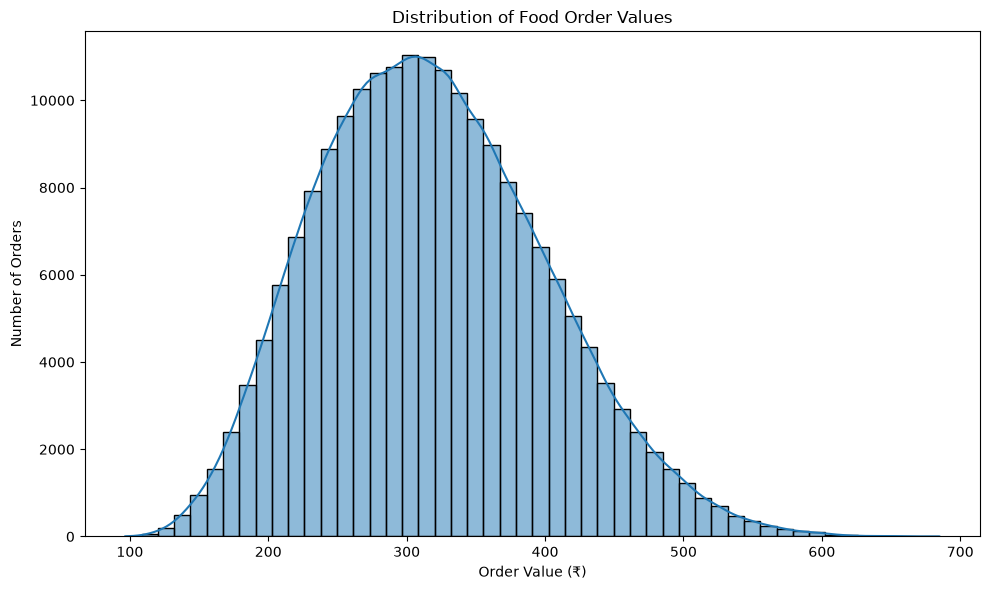

In [14]:
# ============================================================
# ORDER VALUE HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    order_value_sample,
    bins=50,
    kde=True
)

plt.title("Distribution of Food Order Values")
plt.xlabel("Order Value (₹)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

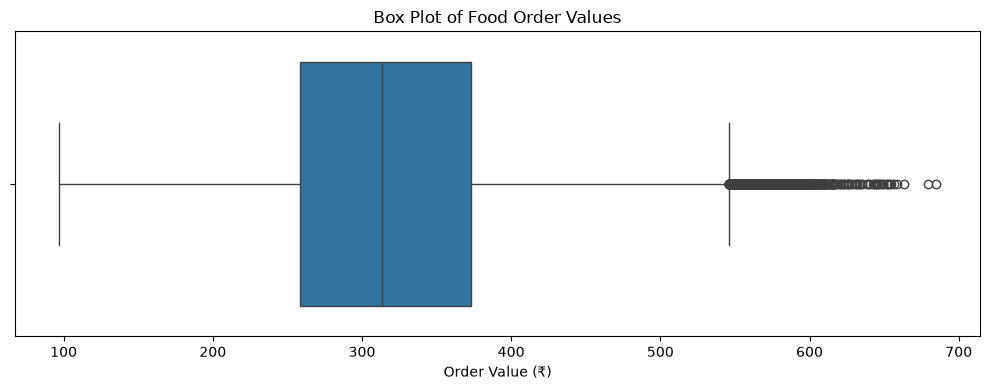

In [15]:
# ============================================================
# ORDER VALUE BOX PLOT
# ============================================================

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=order_value_sample
)

plt.title("Box Plot of Food Order Values")
plt.xlabel("Order Value (₹)")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# ORDER VALUE QUANTILES
# ============================================================

order_value_quantiles = (
    orders_df["order_value"]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .reset_index()
)

order_value_quantiles.columns = [
    "Quantile",
    "Order_Value"
]

order_value_quantiles

,Quantile,Order_Value
0,0.01,158.57
1,0.05,193.79
2,0.25,258.43
3,0.50,313.55
4,0.75,372.96
5,0.95,462.06
6,0.99,523.69


### Order Value Distribution Observations

- The order-value histogram shows that most transactions are concentrated around the ₹250–₹400 range.
- The distribution has a noticeable right tail extending toward higher order values.
- The distribution is positively skewed, indicating that high-value transactions occur less frequently than typical transactions.
- The box plot identifies several higher-value observations beyond the upper whisker.
- These extreme observations are retained because they represent variation produced by the synthetic order-generation process.
- The distribution is therefore not perfectly symmetric and provides useful variation for subsequent behavioral and forecasting analysis.

## 03.2.3 — Meal Period Analysis

This section examines the distribution of food orders across different
meal periods to identify major periods of demand concentration and
intraday ordering behavior.

In [17]:
# ============================================================
# 03.2.3 — MEAL PERIOD ORDER ANALYSIS
# ============================================================

meal_period_summary = (
    orders_df
    .groupby("meal_period")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

meal_period_summary["order_percentage"] = (
    meal_period_summary["order_count"]
    / meal_period_summary["order_count"].sum()
    * 100
)

meal_period_summary

,meal_period,order_count,total_order_value,average_order_value,order_percentage
0,Afternoon,1842245,587060107.17,318.67,10.72
1,Dinner,4348447,1385625128.00,318.65,25.30
2,Evening,2218643,707175236.49,318.74,12.91
3,Late_Morning,1976513,629681610.08,318.58,11.50
4,Late_Night,1518626,483987412.27,318.70,8.83
5,Lunch,3910251,1246050027.72,318.66,22.75
6,Morning,1374232,437722731.41,318.52,7.99


In [18]:
# ============================================================
# ORDER MEAL PERIODS CHRONOLOGICALLY
# ============================================================

meal_order = [
    "Late_Night",
    "Morning",
    "Late_Morning",
    "Lunch",
    "Afternoon",
    "Evening",
    "Dinner"
]

meal_period_summary["meal_period"] = pd.Categorical(
    meal_period_summary["meal_period"],
    categories=meal_order,
    ordered=True
)

meal_period_summary = (
    meal_period_summary
    .sort_values("meal_period")
    .reset_index(drop=True)
)

meal_period_summary

,meal_period,order_count,total_order_value,average_order_value,order_percentage
0,Late_Night,1518626,483987412.27,318.70,8.83
1,Morning,1374232,437722731.41,318.52,7.99
2,Late_Morning,1976513,629681610.08,318.58,11.50
3,Lunch,3910251,1246050027.72,318.66,22.75
4,Afternoon,1842245,587060107.17,318.67,10.72
5,Evening,2218643,707175236.49,318.74,12.91
6,Dinner,4348447,1385625128.00,318.65,25.30


### Meal Period Analysis Observations

- Dinner is the highest-demand meal period, accounting for 25.30% of total transactions.
- Lunch is the second-highest-demand period, contributing 22.75% of total transactions.
- Lunch and Dinner together account for approximately 48.05% of all transactions.
- Evening contributes 12.90% of total orders, indicating substantial demand before the dinner peak.
- Late Morning and Afternoon contribute 11.50% and 10.72%, respectively.
- Morning has the lowest order contribution at approximately 7.99%.
- The strong concentration of orders during Lunch and Dinner confirms the presence of distinct intraday demand patterns that are important for hourly food-demand forecasting.

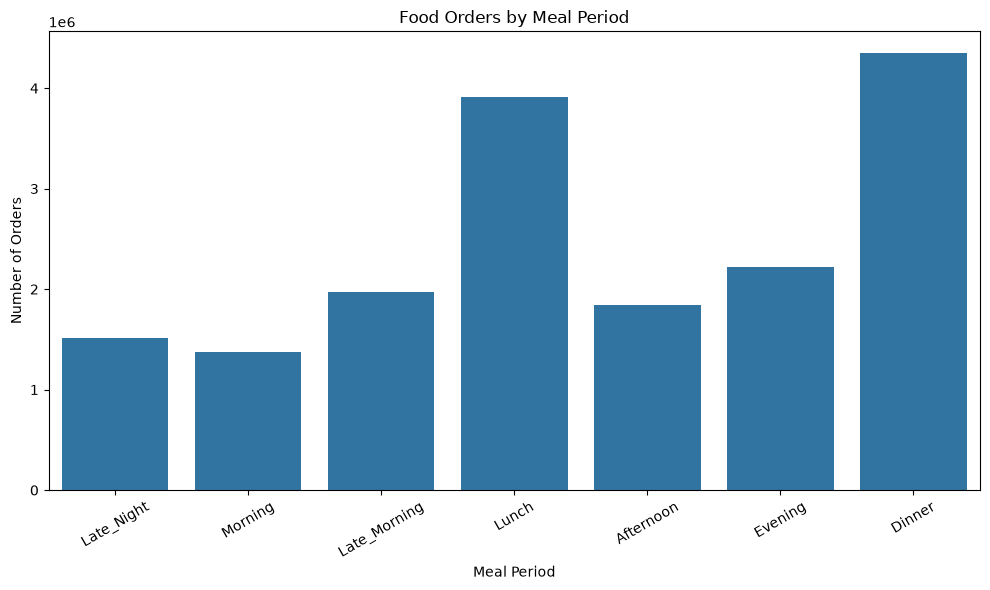

In [19]:
# ============================================================
# MEAL PERIOD ORDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=meal_period_summary,
    x="meal_period",
    y="order_count"
)

plt.title("Food Orders by Meal Period")
plt.xlabel("Meal Period")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 03.2.4 — Weekday vs Weekend Analysis

This section compares food-order volume and order-value characteristics
between weekdays and weekends to identify differences in customer ordering
behavior across day types.

In [20]:
# ============================================================
# 03.2.4 — WEEKDAY VS WEEKEND ANALYSIS
# ============================================================

day_type_summary = (
    orders_df
    .groupby("day_type")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

day_type_summary["order_percentage"] = (
    day_type_summary["order_count"]
    / day_type_summary["order_count"].sum()
    * 100
)

day_type_summary

,day_type,order_count,total_order_value,average_order_value,order_percentage
0,Weekday,11717235,3733676446.47,318.65,68.17
1,Weekend,5471722,1743625806.67,318.66,31.83


In [21]:
# ============================================================
# AVERAGE ORDERS PER CALENDAR DAY
# ============================================================

daily_orders = (
    orders_df
    .assign(order_date=orders_df["order_timestamp"].dt.date)
    .groupby(["order_date", "day_type"])
    .size()
    .reset_index(name="order_count")
)

daily_day_type_summary = (
    daily_orders
    .groupby("day_type")
    .agg(
        average_daily_orders=("order_count", "mean"),
        minimum_daily_orders=("order_count", "min"),
        maximum_daily_orders=("order_count", "max")
    )
    .reset_index()
)

daily_day_type_summary

,day_type,average_daily_orders,minimum_daily_orders,maximum_daily_orders
0,Weekday,12256.52,114,16219
1,Weekend,14286.48,12073,17460


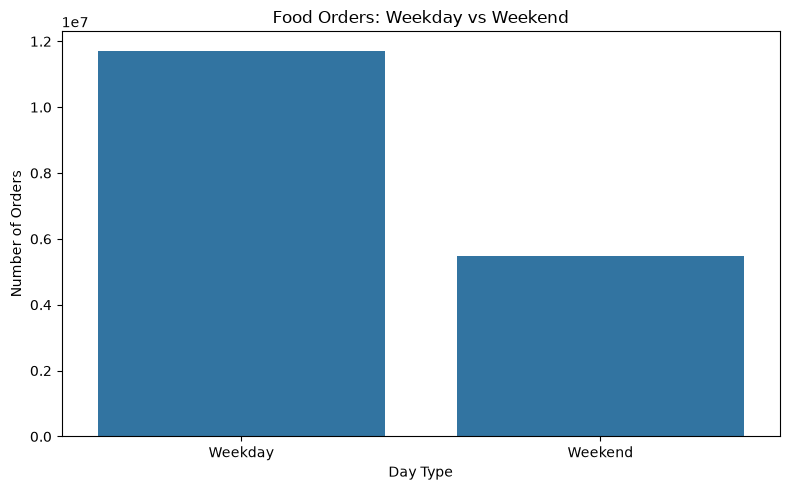

In [22]:
# ============================================================
# WEEKDAY VS WEEKEND ORDER VOLUME
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=day_type_summary,
    x="day_type",
    y="order_count"
)

plt.title("Food Orders: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

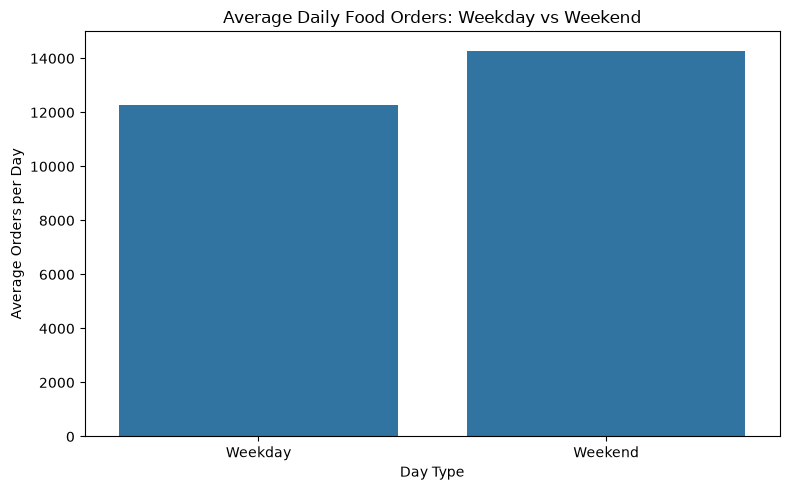

In [23]:
# ============================================================
# AVERAGE DAILY ORDERS BY DAY TYPE
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=daily_day_type_summary,
    x="day_type",
    y="average_daily_orders"
)

plt.title("Average Daily Food Orders: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Orders per Day")

plt.tight_layout()
plt.show()

### Weekday vs Weekend Observations

- Weekdays account for 68.17% of total transactions, while weekends account for 31.83%.
- The higher total weekday volume is expected because there are five weekdays compared with two weekend days in a typical week.
- Average daily order volume provides a more meaningful comparison between the two day types.
- Weekdays have an average of approximately 12,556.52 orders per day.
- Weekends have an average of approximately 14,286.48 orders per day.
- Average daily weekend demand is approximately 13.8% higher than weekday demand.
- This indicates that the synthetic dataset captures stronger daily food-order demand during weekends.
- The observed weekday/weekend difference provides an important temporal pattern for demand forecasting.

## 03.2.5 — Zone-wise Overall Order Contribution

This section examines transaction volume and order-value characteristics
across the five hyperlocal zones. The objective is to identify differences
in overall demand contribution and average order value between zones.

In [24]:
# ============================================================
# 03.2.5 — ZONE-WISE ORDER ANALYSIS
# ============================================================

zone_summary = (
    orders_df
    .groupby("zone_id")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean"),
        unique_customers=("customer_id", "nunique"),
        unique_restaurants=("restaurant_id", "nunique")
    )
    .reset_index()
)

zone_summary["order_percentage"] = (
    zone_summary["order_count"]
    / zone_summary["order_count"].sum()
    * 100
)

zone_summary = zone_summary.sort_values(
    "order_count",
    ascending=False
).reset_index(drop=True)

zone_summary

,zone_id,order_count,total_order_value,average_order_value,unique_customers,unique_restaurants,order_percentage
0,Z02,4250390,1369152828.36,322.12,12121,50,24.73
1,Z03,3911034,1237091639.11,316.31,10936,45,22.75
2,Z05,3209553,1061989092.37,330.88,9926,45,18.67
3,Z04,3127800,969564620.10,309.98,8007,40,18.20
4,Z01,2690180,839504073.20,312.06,9010,40,15.65


In [25]:
# ============================================================
# AVERAGE DAILY ORDERS BY ZONE
# ============================================================

daily_zone_orders = (
    orders_df
    .assign(order_date=orders_df["order_timestamp"].dt.date)
    .groupby(["order_date", "zone_id"])
    .size()
    .reset_index(name="order_count")
)

zone_daily_summary = (
    daily_zone_orders
    .groupby("zone_id")
    .agg(
        average_daily_orders=("order_count", "mean"),
        minimum_daily_orders=("order_count", "min"),
        maximum_daily_orders=("order_count", "max")
    )
    .reset_index()
    .sort_values("average_daily_orders", ascending=False)
)

zone_daily_summary

,zone_id,average_daily_orders,minimum_daily_orders,maximum_daily_orders
1,Z02,3174.30,30,4388
2,Z03,2920.86,23,4103
4,Z05,2396.98,23,3343
3,Z04,2335.92,19,3232
0,Z01,2009.10,19,2833


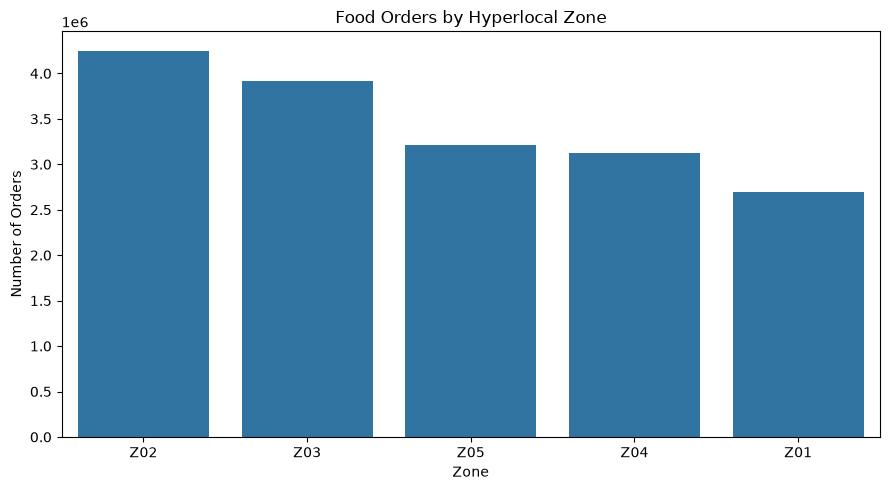

In [26]:
# ============================================================
# ZONE-WISE ORDER VOLUME
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=zone_summary,
    x="zone_id",
    y="order_count"
)

plt.title("Food Orders by Hyperlocal Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

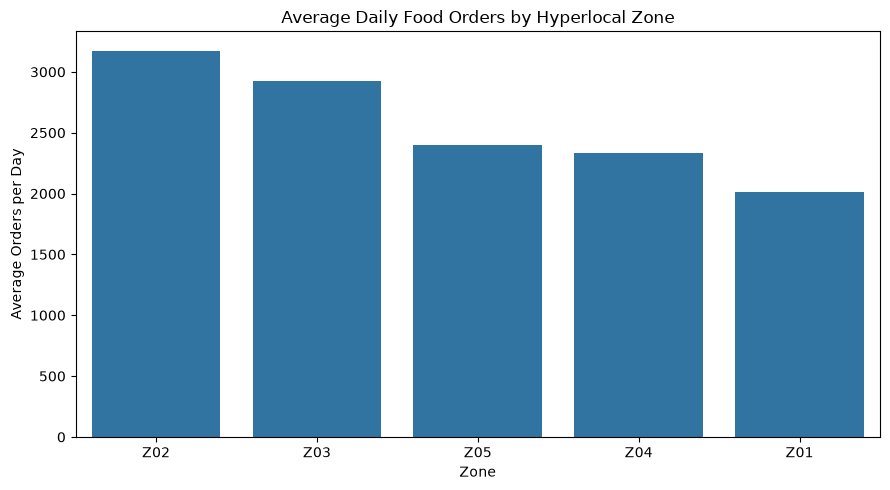

In [27]:
# ============================================================
# AVERAGE DAILY ORDERS BY ZONE
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=zone_daily_summary,
    x="zone_id",
    y="average_daily_orders"
)

plt.title("Average Daily Food Orders by Hyperlocal Zone")
plt.xlabel("Zone")
plt.ylabel("Average Orders per Day")

plt.tight_layout()
plt.show()

### Zone-wise Demand Observations

- Z02 contributes the highest transaction volume with 4,250,390 orders, representing 24.74% of all transactions.
- Z03 is the second-highest-demand zone with 3,911,034 orders and a 22.75% contribution.
- Z05 and Z04 contribute 18.67% and 18.20% of total transactions, respectively.
- Z01 has the lowest transaction volume at 2,690,180 orders, representing 15.65%.
- The average daily order ranking is consistent with the overall transaction-volume ranking.
- The substantial differences in demand across zones demonstrate meaningful spatial variation in the synthetic dataset.
- These spatial differences support the hyperlocal forecasting design, where demand is modeled separately at zone level rather than treating Hyderabad as a single aggregate market.

## 03.2.6 — Overall EDA Summary

The overall exploratory analysis was performed to understand the major
transaction, order-value, temporal, and spatial characteristics of the
synthetic food-order dataset.

### Key Findings

- The dataset contains 17,188,957 food-order transactions involving
  50,000 customers, 220 restaurants, and five hyperlocal zones.
- The mean order value is ₹318.65 and the median is ₹313.55.
- The middle 50% of order values range from ₹258.43 to ₹372.96.
- The order-value distribution is positively skewed, with a longer
  upper tail and several higher-value observations.
- Dinner is the highest-volume meal period, contributing 25.30% of
  transactions, followed by Lunch at 22.75%.
- Lunch and Dinner together account for approximately 48.05% of all
  transactions.
- Weekend average daily demand is approximately 13.8% higher than
  weekday average daily demand.
- Z02 has the highest transaction contribution at 24.74%, while Z01
  has the lowest at 15.65%.
- The differences in demand across zones demonstrate meaningful
  spatial variation in the synthetic dataset.
- The observed temporal and spatial patterns provide a suitable
  foundation for zone-level and hourly food-demand forecasting.

## 03.3 — Hourly Demand Analysis

This section examines intraday food-order patterns to identify demand
peaks, low-demand periods, and recurring hourly variations across the
study period.

Understanding hourly demand patterns is essential for developing and
evaluating hourly hyperlocal food-demand forecasting models.

In [28]:
# ============================================================
# 03.3.1 — EXTRACT ORDER HOUR
# ============================================================

orders_df["order_hour"] = orders_df["order_timestamp"].dt.hour

print("Order hour extracted successfully.")
print(
    "Hour range:",
    orders_df["order_hour"].min(),
    "to",
    orders_df["order_hour"].max()
)

Order hour extracted successfully.
Hour range: 0 to 23


In [29]:
# ============================================================
# HOURLY ORDER SUMMARY
# ============================================================

hourly_summary = (
    orders_df
    .groupby("order_hour")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

hourly_summary["order_percentage"] = (
    hourly_summary["order_count"]
    / hourly_summary["order_count"].sum()
    * 100
)

hourly_summary

,order_hour,order_count,total_order_value,average_order_value,order_percentage
0,0,179925,57338606.34,318.68,1.05
1,1,161869,51590426.29,318.72,0.94
2,2,143836,45852491.72,318.78,0.84
3,3,134731,42890177.19,318.34,0.78
4,4,134776,42989903.03,318.97,0.78
5,5,161770,51452326.31,318.06,0.94
6,6,224681,71564941.85,318.52,1.31
7,7,404196,128755986.72,318.55,2.35
8,8,583585,185949476.53,318.63,3.40
9,9,673233,214484926.65,318.59,3.92


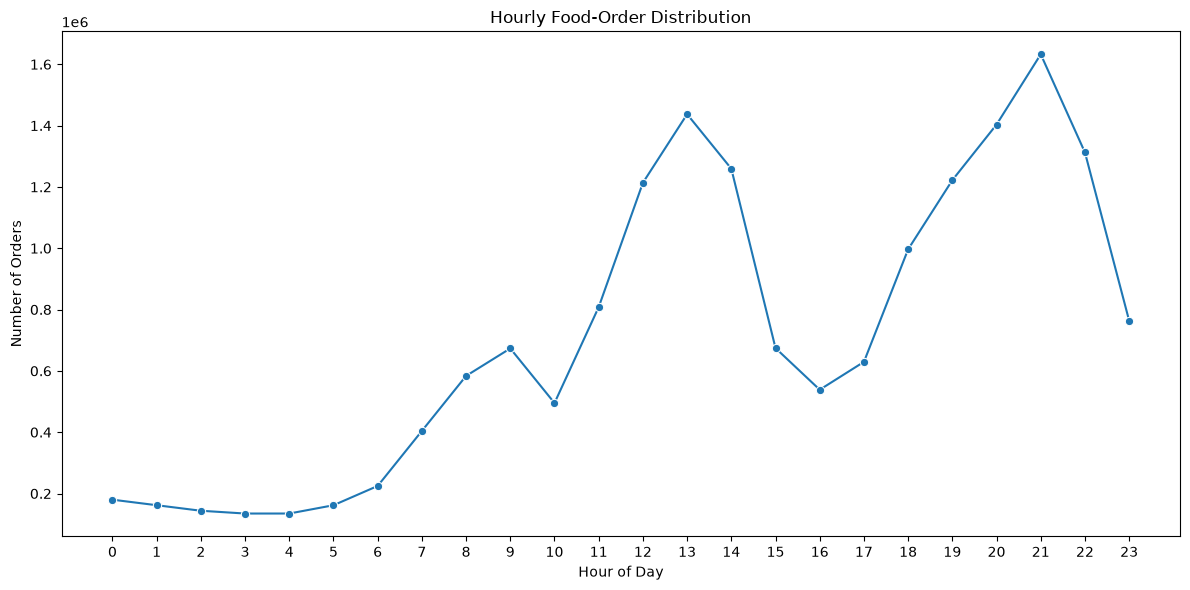

In [30]:
# ============================================================
# HOURLY ORDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_summary,
    x="order_hour",
    y="order_count",
    marker="o"
)

plt.title("Hourly Food-Order Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# PEAK AND LOW-DEMAND HOURS
# ============================================================

peak_hour = hourly_summary.loc[
    hourly_summary["order_count"].idxmax()
]

lowest_hour = hourly_summary.loc[
    hourly_summary["order_count"].idxmin()
]

print("Peak demand hour:")
print(peak_hour)

print("\nLowest demand hour:")
print(lowest_hour)

Peak demand hour:
order_hour                   21.00
order_count             1632592.00
total_order_value     520066436.73
average_order_value         318.55
order_percentage              9.50
Name: 21, dtype: float64

Lowest demand hour:
order_hour                   3.00
order_count             134731.00
total_order_value     42890177.19
average_order_value        318.34
order_percentage             0.78
Name: 3, dtype: float64


### Hourly Demand Observations

- Food-order demand exhibits a clear intraday seasonal pattern across the 24-hour period.
- The highest transaction volume occurs at 21:00, with 1,623,592 orders representing approximately 9.50% of total transactions.
- The lowest transaction volume occurs at 03:00, with 134,731 orders representing approximately 0.78% of total transactions.
- Demand remains relatively low during the early-morning hours and begins increasing during the morning.
- A major demand peak is observed during the lunch period, particularly around 12:00–14:00.
- Demand decreases during the afternoon before increasing again during the evening.
- The strongest demand peak occurs during the dinner period, centered around 21:00.
- The observed hourly variation demonstrates strong intraday seasonality that is highly relevant to hourly food-demand forecasting.

## 03.3.2 — Hourly Demand by Hyperlocal Zone

This section examines hourly food-order volume separately for each
hyperlocal zone to identify whether intraday demand patterns differ
across zones.

The analysis helps determine whether hourly demand forecasting should
capture both temporal and spatial variation.

In [32]:
# ============================================================
# 03.3.2 — HOURLY DEMAND BY ZONE
# ============================================================

hourly_zone_summary = (
    orders_df
    .groupby(["zone_id", "order_hour"])
    .agg(
        order_count=("order_id", "count"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

hourly_zone_summary["order_percentage"] = (
    hourly_zone_summary.groupby("zone_id")["order_count"]
    .transform(lambda x: x / x.sum() * 100)
)

hourly_zone_summary.head(20)

,zone_id,order_hour,order_count,average_order_value,order_percentage
0,Z01,0,28133,311.42,1.05
1,Z01,1,25359,312.76,0.94
2,Z01,2,22505,310.73,0.84
3,Z01,3,21090,311.24,0.78
4,Z01,4,21101,311.48,0.78
5,Z01,5,25336,311.13,0.94
6,Z01,6,35164,312.34,1.31
7,Z01,7,63374,311.64,2.36
8,Z01,8,91192,312.22,3.39
9,Z01,9,105259,312.37,3.91


In [33]:
# ============================================================
# PEAK HOUR BY ZONE
# ============================================================

peak_hour_by_zone = (
    hourly_zone_summary.loc[
        hourly_zone_summary.groupby("zone_id")["order_count"].idxmax()
    ]
    .sort_values("zone_id")
    .reset_index(drop=True)
)

peak_hour_by_zone

,zone_id,order_hour,order_count,average_order_value,order_percentage
0,Z01,21,255018,312.23,9.48
1,Z02,21,403639,322.07,9.50
2,Z03,21,371529,316.26,9.50
3,Z04,21,297807,309.53,9.52
4,Z05,21,304599,330.80,9.49


In [34]:
# ============================================================
# LOWEST-DEMAND HOUR BY ZONE
# ============================================================

lowest_hour_by_zone = (
    hourly_zone_summary.loc[
        hourly_zone_summary.groupby("zone_id")["order_count"].idxmin()
    ]
    .sort_values("zone_id")
    .reset_index(drop=True)
)

lowest_hour_by_zone

,zone_id,order_hour,order_count,average_order_value,order_percentage
0,Z01,3,21090,311.24,0.78
1,Z02,4,33309,322.63,0.78
2,Z03,4,30632,316.05,0.78
3,Z04,3,24496,310.03,0.78
4,Z05,3,25144,330.49,0.78


In [35]:
# ============================================================
# ZONE × HOUR DEMAND MATRIX
# ============================================================

zone_hour_matrix = (
    hourly_zone_summary
    .pivot(
        index="zone_id",
        columns="order_hour",
        values="order_count"
    )
)

zone_hour_matrix

order_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
zone_id,,,,,,,,,,,,,,,,,,,,,,,,
Z01,28133,25359,22505,21090,21101,25336,35164,63374,91192,105259,77509,126586,189662,225105,196851,105455,84192,98660,156240,192059,219898,255018,204921,119511
Z02,44530,40035,35539,33312,33309,39985,55509,99756,144381,166247,122554,199466,300334,355600,311523,166598,133182,155617,245837,302504,347319,403639,325035,188579
Z03,40915,36835,32744,30689,30632,36868,51124,91902,132985,153372,112661,184185,276127,326993,286708,153345,122350,143203,227124,277446,319243,371529,298430,173624
Z04,32708,29379,26124,24496,24520,29375,40903,73628,105969,122464,90016,146907,221002,261291,229327,122433,98088,114356,181077,222148,255265,297807,239345,139172
Z05,33639,30261,26924,25144,25214,30206,41981,75536,109058,125891,92416,150980,226482,268261,234985,126443,100739,117584,186293,227915,261740,304599,244659,142603


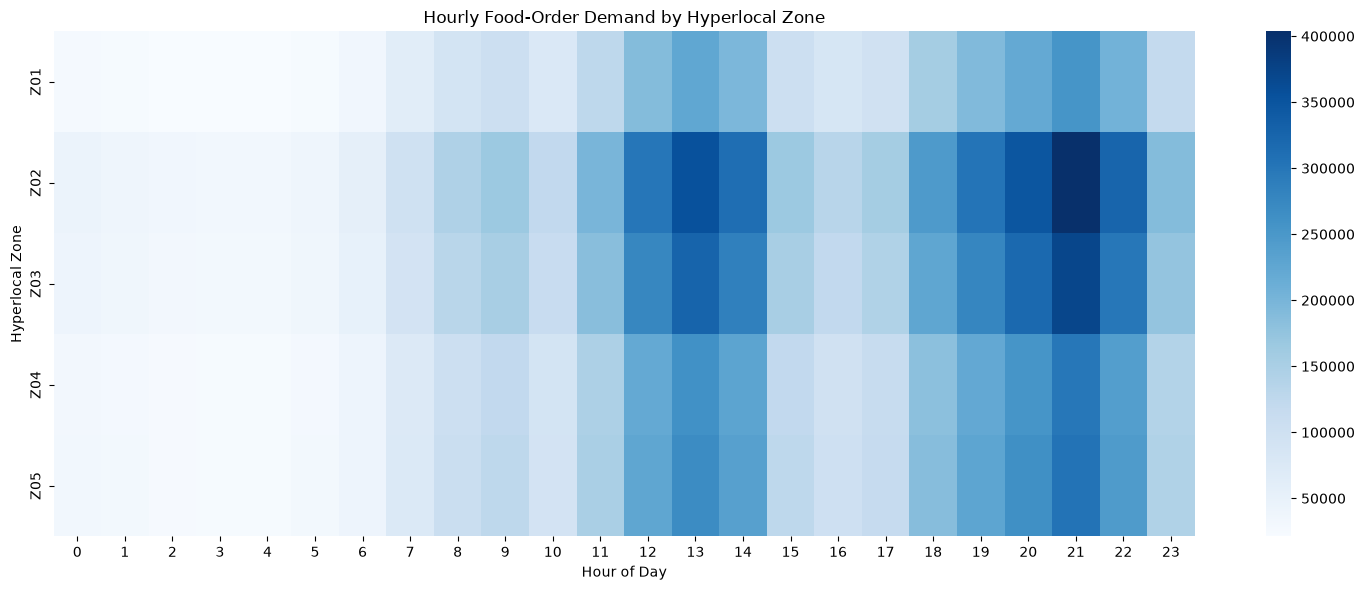

In [36]:
# ============================================================
# ZONE × HOUR DEMAND HEATMAP
# ============================================================

plt.figure(figsize=(15, 6))

sns.heatmap(
    zone_hour_matrix,
    cmap="Blues",
    annot=False,
    fmt=".0f"
)

plt.title("Hourly Food-Order Demand by Hyperlocal Zone")
plt.xlabel("Hour of Day")
plt.ylabel("Hyperlocal Zone")

plt.tight_layout()
plt.show()

### Hourly Demand by Zone — Observations

- All five hyperlocal zones record their highest hourly transaction volume at 21:00.
- The lowest-demand hour occurs around the early-morning period, with Z01 and Z05 reaching their minimum at 03:00 and Z02, Z03, and Z04 reaching their minimum at 04:00.
- The consistent peak timing across zones indicates a common intraday demand cycle in the synthetic dataset.
- Although the timing of peak demand is similar across zones, the magnitude of demand differs substantially between zones.
- Z02 and Z03 consistently exhibit higher absolute demand levels, while Z01 has the lowest overall demand contribution.
- These results demonstrate that the forecasting problem contains both temporal variation and spatial variation.
- Therefore, zone-level forecasting can capture differences in demand magnitude while preserving the common intraday seasonal structure.

## 03.3.3 — Hourly Demand by Day Type

This section compares hourly food-order demand between weekdays and
weekends to determine whether the intraday demand pattern changes
according to day type.

The analysis examines both demand magnitude and hourly demand share.

In [37]:
# ============================================================
# 03.3.3 — HOURLY DEMAND BY DAY TYPE
# ============================================================

hourly_day_type_summary = (
    orders_df
    .groupby(["day_type", "order_hour"])
    .agg(
        order_count=("order_id", "count"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

hourly_day_type_summary["order_percentage"] = (
    hourly_day_type_summary
    .groupby("day_type")["order_count"]
    .transform(lambda x: x / x.sum() * 100)
)

hourly_day_type_summary.head(10)

,day_type,order_hour,order_count,average_order_value,order_percentage
0,Weekday,0,122604,318.66,1.05
1,Weekday,1,110324,318.84,0.94
2,Weekday,2,98122,318.94,0.84
3,Weekday,3,91839,318.25,0.78
4,Weekday,4,91936,319.00,0.78
5,Weekday,5,110303,317.98,0.94
6,Weekday,6,153161,318.37,1.31
7,Weekday,7,275436,318.46,2.35
8,Weekday,8,397762,318.56,3.39
9,Weekday,9,459133,318.49,3.92


In [38]:
# ============================================================
# PEAK HOUR BY DAY TYPE
# ============================================================

peak_hour_by_day_type = (
    hourly_day_type_summary.loc[
        hourly_day_type_summary
        .groupby("day_type")["order_count"]
        .idxmax()
    ]
    .reset_index(drop=True)
)

peak_hour_by_day_type

,day_type,order_hour,order_count,average_order_value,order_percentage
0,Weekday,21,1112008,318.54,9.49
1,Weekend,21,520584,318.59,9.51


In [39]:
# ============================================================
# LOWEST-DEMAND HOUR BY DAY TYPE
# ============================================================

lowest_hour_by_day_type = (
    hourly_day_type_summary.loc[
        hourly_day_type_summary
        .groupby("day_type")["order_count"]
        .idxmin()
    ]
    .reset_index(drop=True)
)

lowest_hour_by_day_type

,day_type,order_hour,order_count,average_order_value,order_percentage
0,Weekday,3,91839,318.25,0.78
1,Weekend,4,42840,318.92,0.78


In [40]:
# ============================================================
# WEEKDAY VS WEEKEND HOURLY DEMAND MATRIX
# ============================================================

day_type_hour_matrix = (
    hourly_day_type_summary
    .pivot(
        index="order_hour",
        columns="day_type",
        values="order_count"
    )
)

day_type_hour_matrix

day_type,Weekday,Weekend
order_hour,,
0,122604,57321
1,110324,51545
2,98122,45714
3,91839,42892
4,91936,42840
5,110303,51467
6,153161,71520
7,275436,128760
8,397762,185823


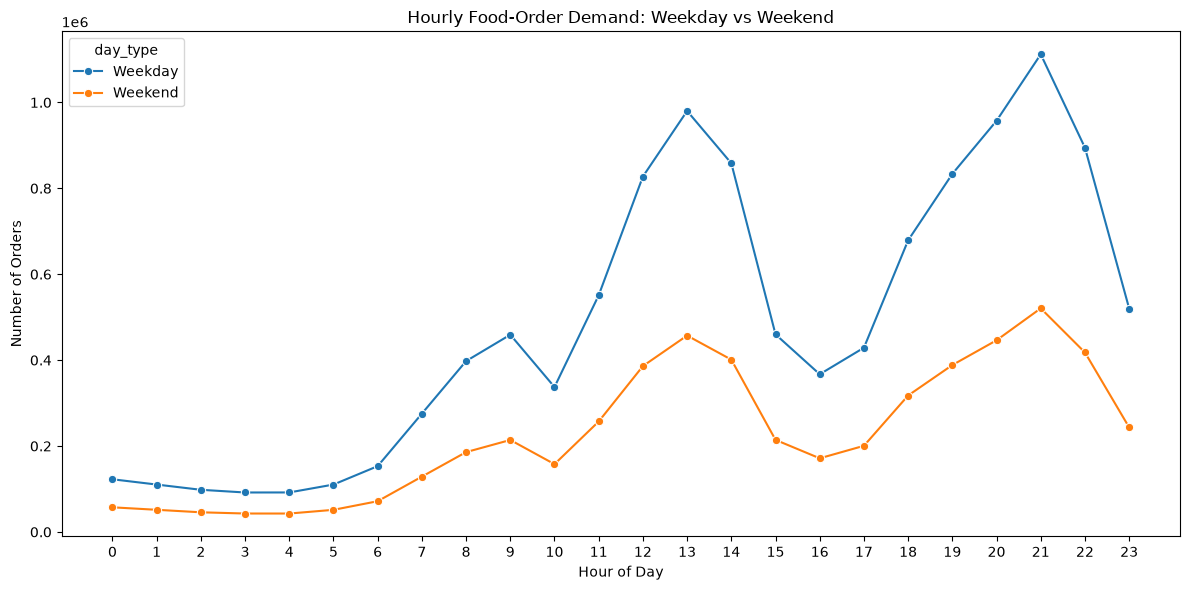

In [41]:
# ============================================================
# WEEKDAY VS WEEKEND HOURLY DEMAND
# ============================================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_day_type_summary,
    x="order_hour",
    y="order_count",
    hue="day_type",
    marker="o"
)

plt.title("Hourly Food-Order Demand: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

### Hourly Demand by Day Type — Observations

- Both weekdays and weekends reach their highest hourly demand at 21:00.
- Weekday demand peaks at approximately 1,112,008 orders at 21:00, representing 9.49% of weekday transactions.
- Weekend demand peaks at approximately 520,584 orders at 21:00, representing 9.51% of weekend transactions.
- The lowest weekday demand occurs at 03:00, while the lowest weekend demand occurs at 04:00.
- Both day types exhibit a similar intraday demand shape, characterized by low early-morning demand, a lunch-period increase, an afternoon decline, an evening recovery, and a strong dinner peak.
- The similar peak-hour shares indicate that the underlying hourly demand structure remains broadly consistent across weekdays and weekends.
- Differences in overall demand magnitude are influenced by the different number of weekdays and weekend days within a typical week.
- The results indicate that both hour-of-day and day type are important dimensions for subsequent demand forecasting analysis.

## 03.3.4 — Day-of-Week Demand Analysis

This section examines food-order demand across the seven days of the
week to identify recurring weekly patterns and differences in demand
between individual weekdays and weekend days.

In [42]:
# ============================================================
# 03.3.4 — DAY-OF-WEEK DEMAND ANALYSIS
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_of_week_summary = (
    orders_df
    .groupby("day_of_week")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

day_of_week_summary["order_percentage"] = (
    day_of_week_summary["order_count"]
    / day_of_week_summary["order_count"].sum()
    * 100
)

day_of_week_summary["day_of_week"] = pd.Categorical(
    day_of_week_summary["day_of_week"],
    categories=day_order,
    ordered=True
)

day_of_week_summary = (
    day_of_week_summary
    .sort_values("day_of_week")
    .reset_index(drop=True)
)

day_of_week_summary

,day_of_week,order_count,total_order_value,average_order_value,order_percentage
0,Monday,2088902,665730725.89,318.70,12.15
1,Tuesday,2206706,703104440.79,318.62,12.84
2,Wednesday,2321640,739887196.88,318.69,13.51
3,Thursday,2434795,775862046.99,318.66,14.16
4,Friday,2665192,849092035.92,318.59,15.51
5,Saturday,2901524,924433457.67,318.60,16.88
6,Sunday,2570198,819192349.00,318.73,14.95


### Day-of-Week Demand Observations

- Saturday records the highest transaction volume with 2,901,524 orders, representing 16.88% of total transactions.
- Monday records the lowest transaction volume with 2,088,902 orders, representing 12.15% of total transactions.
- Order volume generally increases from Monday through Saturday.
- Friday shows a substantial increase in demand compared with the earlier weekdays.
- Saturday represents the strongest day-of-week demand, followed by Sunday.
- Sunday demand decreases compared with Saturday but remains higher than most weekdays.
- Average order values remain relatively stable across all seven days, indicating that day-of-week variation is primarily associated with order volume rather than transaction value.
- The observed weekly pattern demonstrates recurring day-of-week seasonality that can be relevant to hourly demand forecasting.

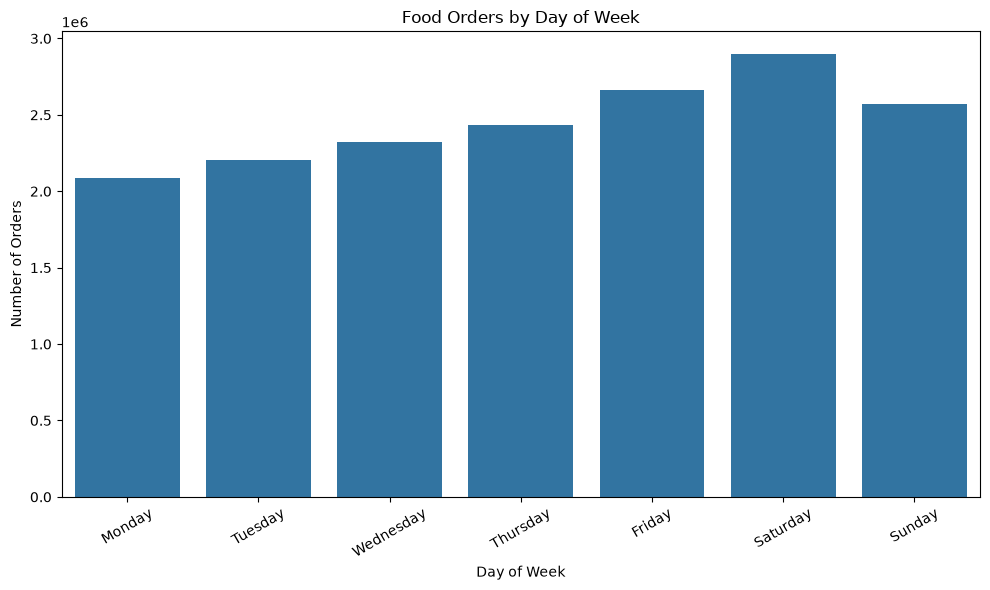

In [43]:
# ============================================================
# DAY-OF-WEEK ORDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=day_of_week_summary,
    x="day_of_week",
    y="order_count"
)

plt.title("Food Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()